In [1]:
import pandas as pd
import numpy as np

In [2]:
%pwd
%cd /home/jovyan/work/results/Cell/
%pwd

/home/jovyan/work/results/Cell


'/home/jovyan/work/results/Cell'

In [3]:
# import the PCC data
pcc_4S = pd.read_csv("pcc_4S.csv", index_col=0)
pcc_I = pd.read_csv("pcc_I.csv", index_col=0)
pcc_III = pd.read_csv("pcc_III.csv", index_col=0)
pcc_IV = pd.read_csv("pcc_IV.csv", index_col=0)
# pcc_NA = pd.read_csv("pcc_NA.csv", index_col=0)
pcc_4S

,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,1.000000,0.101876,-0.105444,0.294110,0.285490,0.043094,0.273760,0.154205,0.535308,0.574785,...,-0.214314,-0.225862,0.491546,0.099288,0.247549,-0.177206,0.227948,-0.268659,0.047149,-0.721479
DPM1,0.101876,1.000000,0.040753,0.366840,0.112091,-0.203120,0.277659,0.230100,0.012097,-0.223822,...,-0.017635,-0.288416,0.410572,0.095112,0.348526,0.411757,-0.319794,-0.130364,0.225836,-0.290486
SCYL3,-0.105444,0.040753,1.000000,0.378629,-0.077102,0.299282,0.164965,0.239981,-0.208912,0.051952,...,0.622151,0.586767,0.021289,0.030100,0.392734,0.130584,0.244455,0.441587,0.019297,0.122590
C1orf112,0.294110,0.366840,0.378629,1.000000,0.090887,0.202204,0.276277,0.408218,-0.028448,0.043607,...,0.243748,0.095764,0.304032,0.119730,0.447024,-0.121551,0.210028,0.290213,-0.177887,-0.509990
FGR,0.285490,0.112091,-0.077102,0.090887,1.000000,-0.117195,0.082018,-0.002028,0.309746,0.378912,...,0.061240,0.080967,0.612712,0.711971,0.284195,0.071398,0.207367,-0.222435,0.442745,-0.239477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,-0.177206,0.411757,0.130584,-0.121551,0.071398,-0.431935,-0.214156,-0.163260,0.100622,-0.076020,...,0.350383,0.075384,0.190224,0.019012,0.208961,1.000000,-0.613841,-0.308633,0.599359,0.277204
CYB561D2,0.227948,-0.319794,0.244455,0.210028,0.207367,0.558621,0.306613,0.189181,0.124066,0.351359,...,0.070697,0.309529,0.159834,0.172155,0.138332,-0.613841,1.000000,0.342137,-0.458748,-0.186283
CCDC7,-0.268659,-0.130364,0.441587,0.290213,-0.222435,0.542627,0.210271,0.254534,-0.347429,-0.078083,...,0.285602,0.507611,-0.117943,-0.003734,0.117266,-0.308633,0.342137,1.000000,-0.371967,0.101145


construct a weighted graph of edges based on 1-abs(PCC-value)

delete rows and columns with Inf entries, since those genes are deleted from the module. (already ensured the genes won't contribute to potential modules candidates by assuring only 1 connected component is >= 3 in the previous graph)

In [4]:
import sys
sys.path.append('/home/jovyan/work/FUNCTIONS/')
from methods import Linear_SWIM_pcc_to_distance

In [5]:
%pwd
%cd /home/jovyan/work/parameter_tuning/Linear_SWIM/Cell/
%pwd

/home/jovyan/work/parameter_tuning/Linear_SWIM/Cell


'/home/jovyan/work/parameter_tuning/Linear_SWIM/Cell'

IGRAPH UNW- 12939 1322561 -- 
+ attr: name (v), weight (e)
graph is connected: False


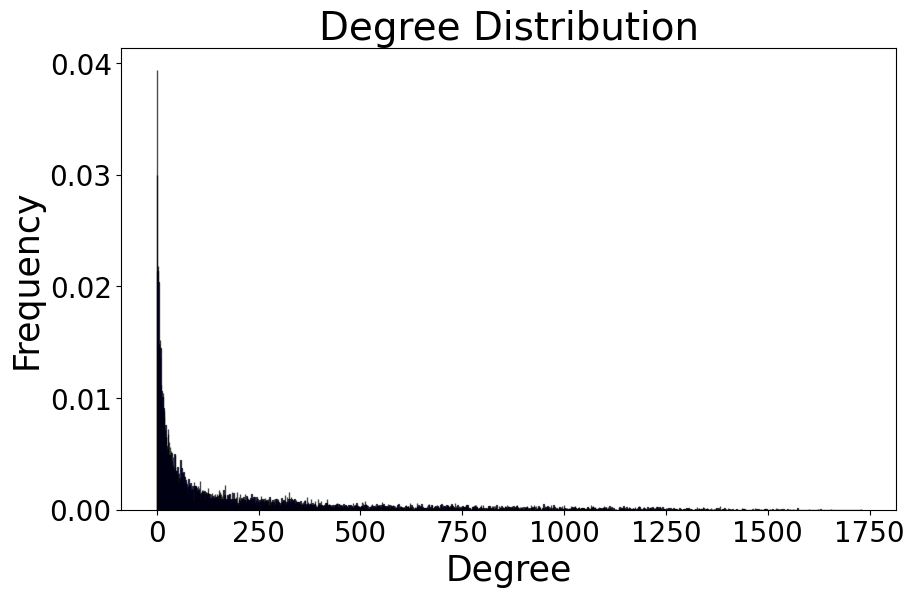

All Pairs Distances:
<class 'list'>
12939X12939


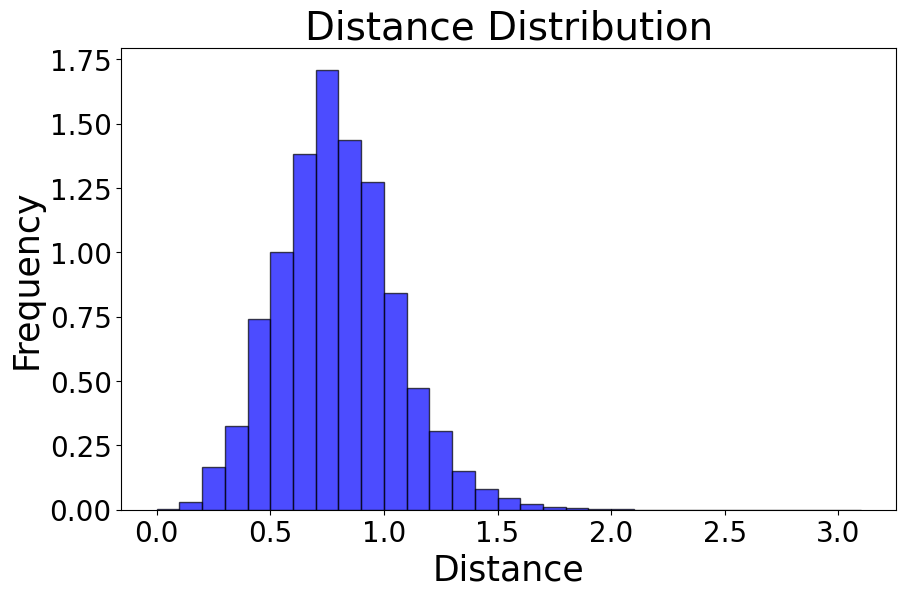

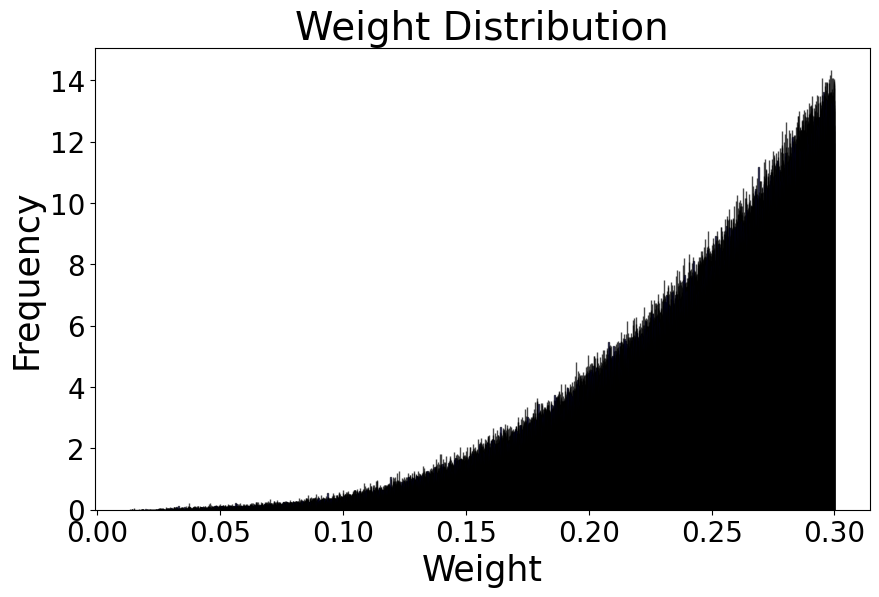

Number of vertices in largest connected component: 12390
Number of edges in largest connected component: 1322541


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,LINC01176,SEPSECS-AS1,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000000,0.773897,0.703237,0.680294,0.641601,0.932403,0.642840,0.871225,0.526939,0.545899,...,0.738398,1.021534,0.593825,0.744499,0.778509,0.670417,0.677001,0.717391,0.949935,0.278521
DPM1,0.773897,0.000000,0.766109,0.590894,0.824524,0.948819,0.590362,0.753948,0.924640,0.816038,...,0.725012,1.145491,0.783683,0.891021,0.929501,0.549146,0.831691,0.800076,0.800544,0.604077
SCYL3,0.703237,0.766109,0.000000,0.729685,0.839800,0.855578,0.920618,0.836668,0.764158,0.907570,...,0.797875,0.829310,0.952175,1.058118,0.832073,0.799766,0.862807,0.639342,1.055671,0.662947
C1orf112,0.680294,0.590894,0.729685,0.000000,0.784112,0.677189,0.634887,0.702711,0.964767,0.812670,...,0.425192,1.159817,0.756361,0.932474,0.743247,0.672784,0.651520,0.627736,0.938310,0.482961
FGR,0.641601,0.824524,0.839800,0.784112,0.000000,0.949113,0.880398,1.116074,0.631834,0.672725,...,0.780782,1.143568,0.356712,0.288029,0.741138,0.875168,0.760975,0.916372,0.686201,0.724755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,0.670417,0.549146,0.799766,0.672784,0.875168,0.719538,0.663468,0.846457,0.916438,0.795607,...,0.546080,1.093692,0.866292,0.923138,0.928838,0.000000,0.439779,0.549174,0.450581,0.527497
CYB561D2,0.677001,0.831691,0.862807,0.651520,0.760975,0.747418,0.673582,0.841441,0.852502,0.691066,...,0.575123,1.224633,0.841054,0.900323,0.907297,0.439779,0.000000,0.548301,0.730473,0.665477
CCDC7,0.717391,0.800076,0.639342,0.627736,0.916372,0.538260,0.664552,0.717312,0.901846,0.847528,...,0.523721,0.801145,0.982249,1.012634,0.907546,0.549174,0.548301,0.000000,0.814700,0.706725


In [6]:
distance_4S = Linear_SWIM_pcc_to_distance(pcc_matrix=pcc_4S, fig_path1="./figures/degree_distribution_4S.svg", fig_path2="./figures/distance_distribution_4S.svg", fig_path3="./figures/weight_distribution_4S.svg", pcc_threshold=0.7)
distance_4S.to_csv("distance_4S.csv")
distance_4S

IGRAPH UNW- 12939 1215109 -- 
+ attr: name (v), weight (e)
graph is connected: False


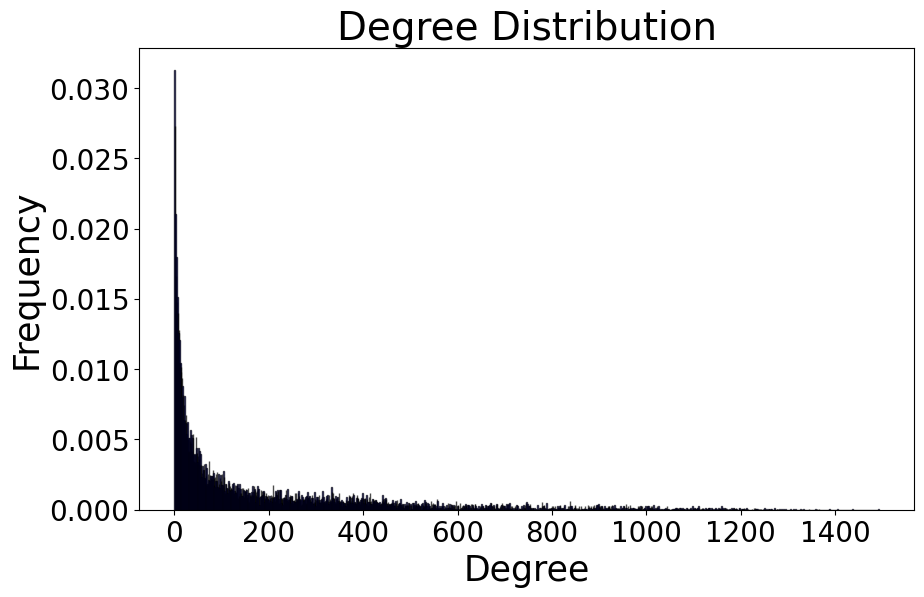

All Pairs Distances:
<class 'list'>
12939X12939


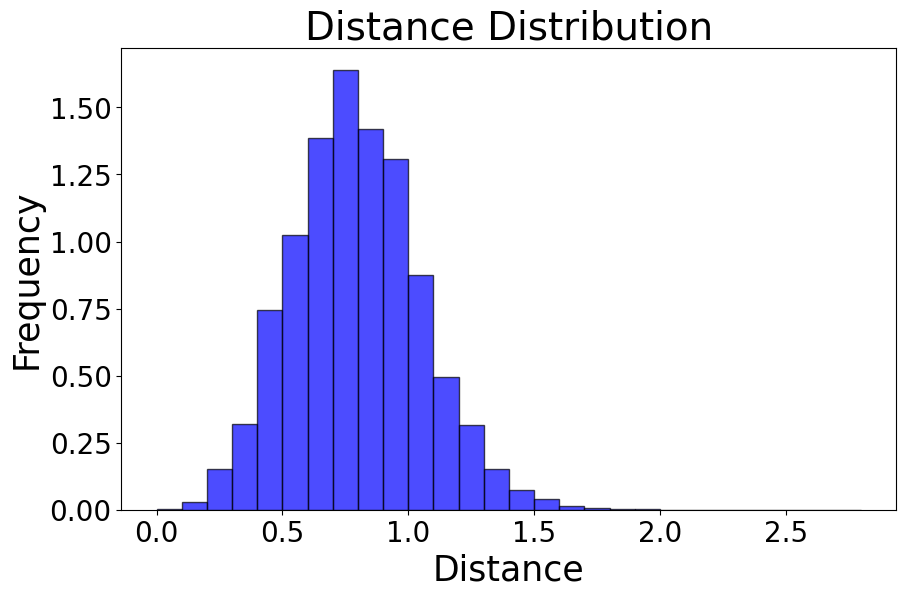

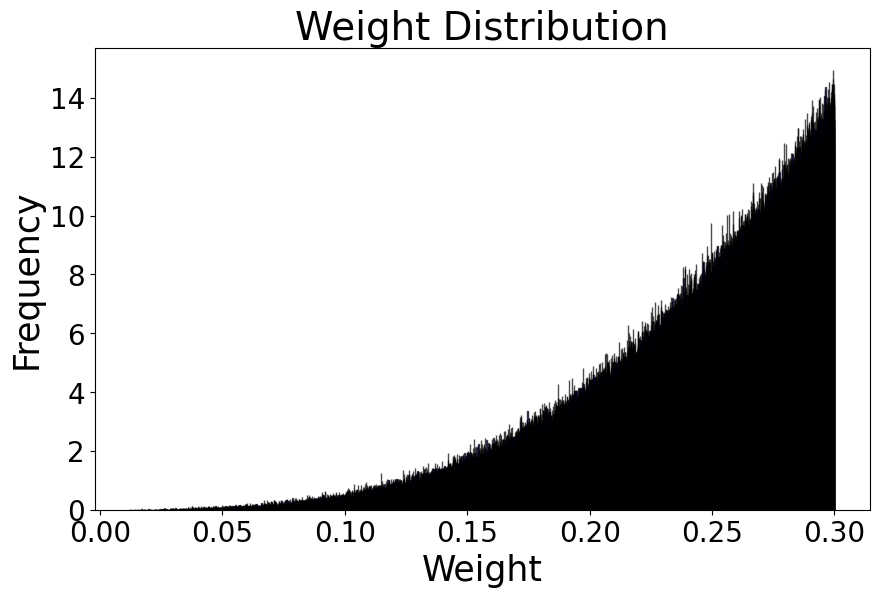

Number of vertices in largest connected component: 12515
Number of edges in largest connected component: 1215099


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,LINC01176,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000000,0.847576,1.071678,0.994782,0.950946,1.007262,0.729045,0.904330,0.801008,1.095487,...,1.152425,1.128811,0.832541,0.970381,1.042610,0.891117,1.097370,0.940797,0.839789,0.865798
DPM1,0.847576,0.000000,0.883875,0.425029,0.917574,0.832529,0.708258,0.809863,0.805208,0.687971,...,0.764824,1.210997,0.890499,0.984152,0.789222,0.580074,0.762999,0.750998,0.641583,0.739440
SCYL3,1.071678,0.883875,0.000000,0.688142,1.025974,0.692698,0.643575,0.622281,0.885376,0.963547,...,0.728542,0.849184,1.084111,1.060830,0.543954,0.597576,0.761217,0.513763,0.736402,0.871311
C1orf112,0.994782,0.425029,0.688142,0.000000,0.905622,0.734934,0.665798,0.493090,0.763050,0.528914,...,0.519256,1.119552,0.904348,0.817274,0.772749,0.542464,0.785245,0.651732,0.757082,0.649809
FGR,0.950946,0.917574,1.025974,0.905622,0.000000,0.820390,0.828746,0.893674,0.607454,0.737662,...,0.931391,0.516736,0.278022,0.276877,0.482020,0.539361,0.760097,0.841482,0.549306,0.958653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,0.891117,0.580074,0.597576,0.542464,0.539361,0.423510,0.585644,0.538926,0.366430,0.455431,...,0.685955,0.752860,0.592231,0.677475,0.832094,0.000000,0.279949,0.373039,0.234094,0.611753
CYB561D2,1.097370,0.762999,0.761217,0.785245,0.760097,0.426006,0.672810,0.676449,0.587233,0.735380,...,0.868542,0.966239,0.793746,0.898210,0.960485,0.279949,0.000000,0.471949,0.375547,0.715440
CCDC7,0.940797,0.750998,0.513763,0.651732,0.841482,0.360077,0.613760,0.563974,0.619857,0.774045,...,0.776559,0.938802,0.837677,0.879985,0.765730,0.373039,0.471949,0.000000,0.431161,0.634183


In [7]:
distance_I = Linear_SWIM_pcc_to_distance(pcc_matrix=pcc_I, fig_path1="./figures/degree_distribution_I.svg", fig_path2="./figures/distance_distribution_I.svg", fig_path3="./figures/weight_distribution_I.svg", pcc_threshold=0.7)
distance_I.to_csv("distance_I.csv")
distance_I

IGRAPH UNW- 12939 1856546 -- 
+ attr: name (v), weight (e)
graph is connected: False


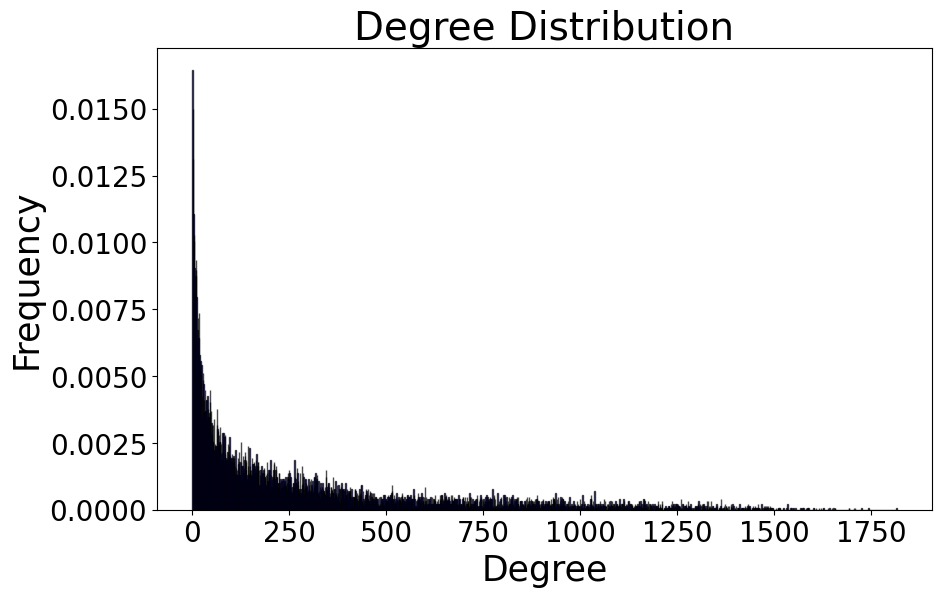

All Pairs Distances:
<class 'list'>
12939X12939


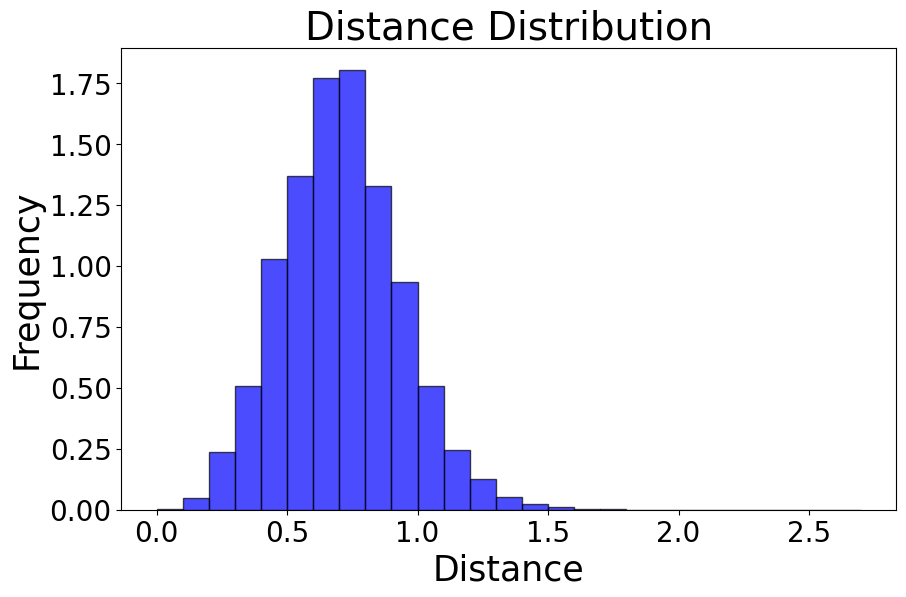

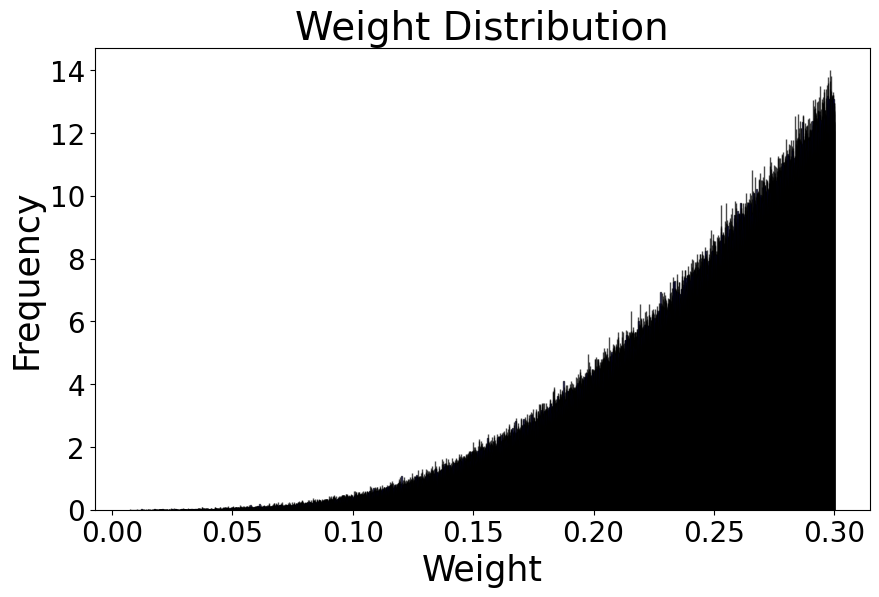

Number of vertices in largest connected component: 12707
Number of edges in largest connected component: 1856535


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,GCLC,NFYA,STPG1,NIPAL3,LAS1L,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000000,0.826027,0.486723,0.722761,0.895446,0.739586,0.729178,0.453422,0.465390,0.379545,...,0.865733,0.802033,0.802755,0.940207,0.798345,0.971772,1.219680,0.525260,0.707520,0.620416
DPM1,0.826027,0.000000,0.731299,0.624930,1.017822,1.012244,0.807037,0.928962,0.802940,0.877177,...,1.118591,1.122327,0.938096,0.972337,0.937057,0.966895,1.346006,0.868210,0.839035,0.796627
SCYL3,0.486723,0.731299,0.000000,0.518787,0.632604,0.633700,0.522441,0.649778,0.614260,0.583808,...,0.807825,0.569142,0.640289,0.755377,0.448594,0.796813,1.269187,0.368289,0.491762,0.563292
C1orf112,0.722761,0.624930,0.518787,0.000000,0.734462,0.561982,0.462133,0.684412,0.711405,0.498141,...,0.818109,0.873871,0.703671,0.944715,0.667241,0.940155,0.988472,0.683008,0.810535,0.721679
FGR,0.895446,1.017822,0.632604,0.734462,0.000000,0.802171,0.719598,0.831663,0.926967,0.872481,...,1.200315,0.569785,0.354723,0.291040,0.782487,0.910439,1.258050,0.644956,0.790103,0.663527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,0.971772,0.966895,0.796813,0.940155,0.910439,1.112490,0.846388,0.987756,1.062114,0.938515,...,1.266951,1.029376,0.877299,1.046543,1.009684,0.000000,1.586428,0.841721,0.710644,0.858293
CYB561D2,1.219680,1.346006,1.269187,0.988472,1.258050,1.216859,1.272155,1.153613,1.259099,0.982408,...,1.655136,1.282817,1.024928,1.265957,1.484591,1.586428,0.000000,1.264259,1.409036,1.365443
CCDC7,0.525260,0.868210,0.368289,0.683008,0.644956,0.583161,0.590202,0.657222,0.627534,0.567358,...,0.909967,0.456757,0.498330,0.656463,0.641951,0.841721,1.264259,0.000000,0.651450,0.558484


In [9]:
distance_III = Linear_SWIM_pcc_to_distance(pcc_matrix=pcc_III, fig_path1="./figures/degree_distribution_III.svg", fig_path2="./figures/distance_distribution_III.svg", fig_path3="./figures/weight_distribution_III.svg", pcc_threshold=0.7)
distance_III.to_csv("distance_III.csv")
distance_III

IGRAPH UNW- 12939 2022063 -- 
+ attr: name (v), weight (e)
graph is connected: False


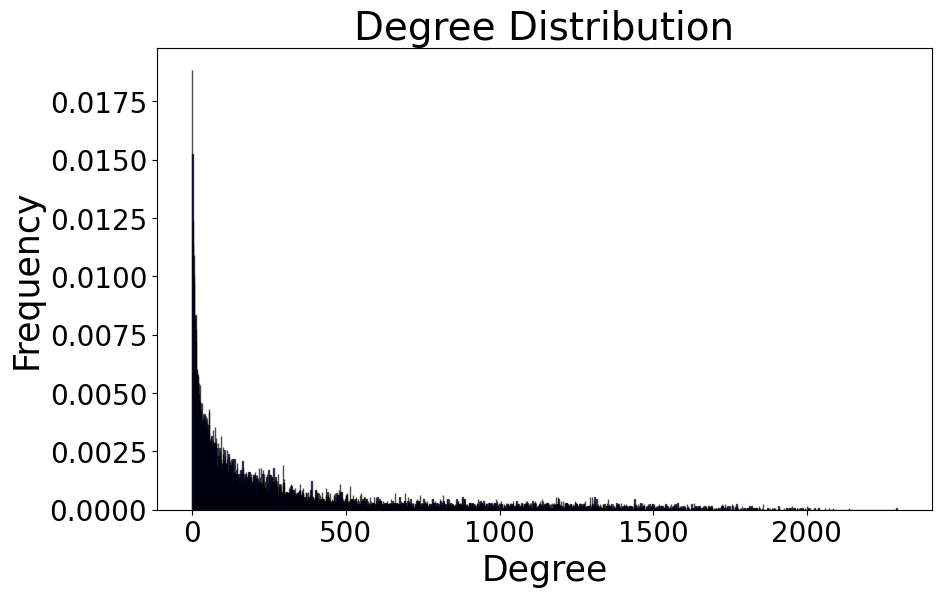

All Pairs Distances:
<class 'list'>
12939X12939


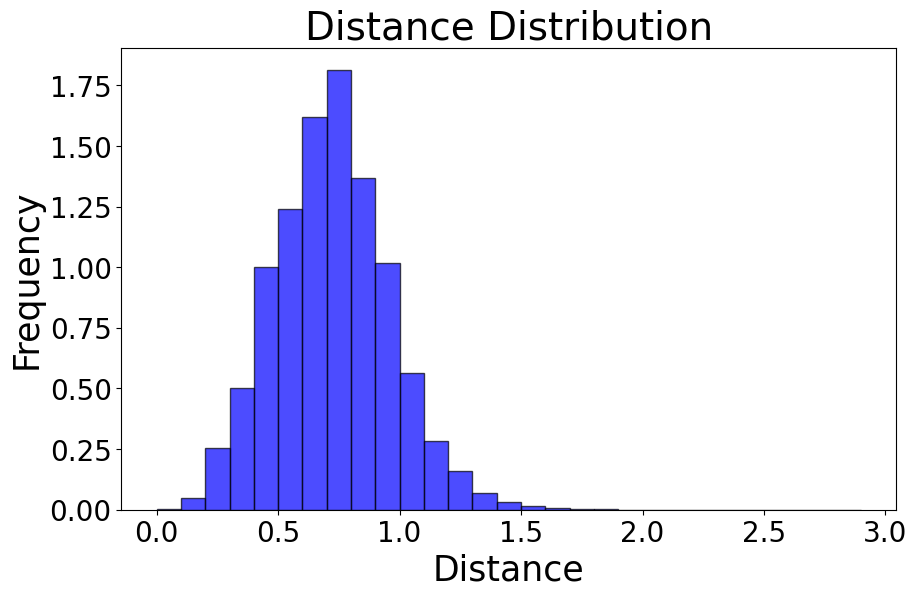

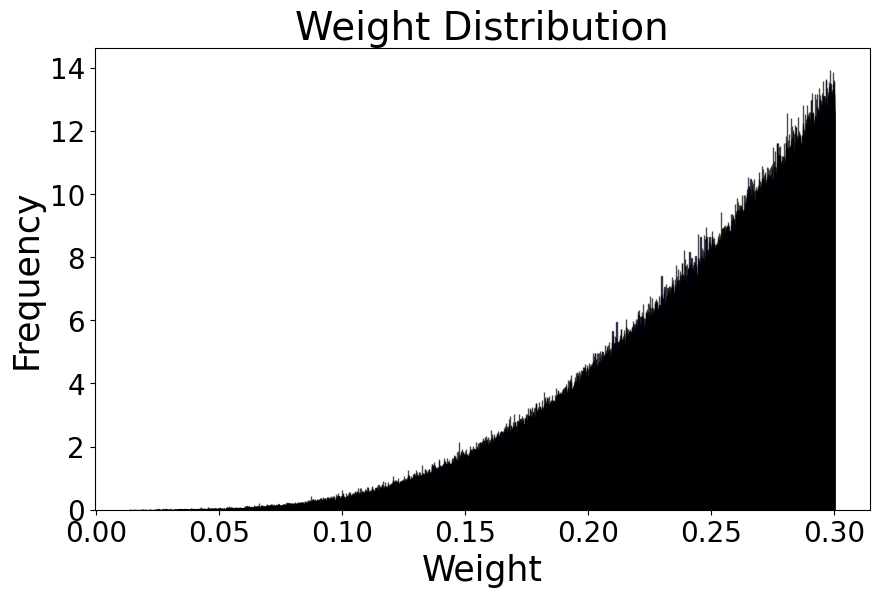

Number of vertices in largest connected component: 12677
Number of edges in largest connected component: 2022053


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,LAS1L,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000000,0.692938,0.638131,0.685656,0.958106,0.788393,0.706246,0.608254,0.938858,0.573822,...,0.828785,0.501275,1.021081,1.044344,0.793191,0.666161,0.575200,0.859252,0.753258,0.247799
DPM1,0.692938,0.000000,0.666882,0.678507,0.804723,0.829828,0.760323,0.654633,1.139588,0.686027,...,0.845078,0.991047,0.751934,1.090626,0.702197,0.703308,0.650591,1.200349,0.667451,0.705418
SCYL3,0.638131,0.666882,0.000000,0.518860,0.766001,0.526497,0.436678,0.356399,0.788738,0.399728,...,0.438716,0.654296,0.917524,0.779749,0.411993,0.532874,0.325533,0.930316,0.539445,0.581978
C1orf112,0.685656,0.678507,0.518860,0.000000,0.901772,0.548187,0.453275,0.307232,0.835755,0.264316,...,0.431551,0.801155,0.924126,0.808084,0.524344,0.415064,0.326072,1.010205,0.500529,0.600806
FGR,0.958106,0.804723,0.766001,0.901772,0.000000,1.015397,0.768825,0.698602,1.045759,0.741821,...,0.738168,0.728473,0.515998,0.362769,0.533021,0.853269,0.691465,1.174806,0.806844,0.710307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,0.666161,0.703308,0.532874,0.415064,0.853269,0.512120,0.571558,0.476136,0.882788,0.295811,...,0.659367,0.578394,0.789456,0.767785,0.659685,0.000000,0.251175,0.804270,0.211670,0.419759
CYB561D2,0.575200,0.650591,0.325533,0.326072,0.691465,0.367915,0.405917,0.341759,0.734063,0.152447,...,0.433862,0.671596,0.920222,0.587115,0.535343,0.251175,0.000000,0.882922,0.249336,0.457569
CCDC7,0.859252,1.200349,0.930316,1.010205,1.174806,1.049382,1.005060,0.914918,1.095864,0.927047,...,1.070026,0.685247,1.071457,1.135207,0.992350,0.804270,0.882922,0.000000,0.914758,0.648579


In [10]:
distance_IV = Linear_SWIM_pcc_to_distance(pcc_matrix=pcc_IV, fig_path1="./figures/degree_distribution_IV.svg", fig_path2="./figures/distance_distribution_IV.svg", fig_path3="./figures/weight_distribution_IV.svg", pcc_threshold=0.7)
distance_IV.to_csv("distance_IV.csv")
distance_IV